In [1]:
#Environment Setup

# Core libraries
import os
import gc
import math
import random
import numpy as np
import pandas as pd
from pathlib import Path

# Visualization
import matplotlib.pyplot as plt

# Deep Learning
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader

# Progress bars
from tqdm.auto import tqdm


In [2]:
# Global Configuration

class CFG:
    COMPETITION_DIR = Path("/kaggle/input/competitions/stanford-rna-3d-folding-2")
    TRAIN_SEQ_PATH = COMPETITION_DIR / "train_sequences.csv"
    VAL_SEQ_PATH   = COMPETITION_DIR / "validation_sequences.csv"
    TEST_SEQ_PATH  = COMPETITION_DIR / "test_sequences.csv"
    TRAIN_LABELS_PATH = COMPETITION_DIR / "train_labels.csv"
    VAL_LABELS_PATH   = COMPETITION_DIR / "validation_labels.csv"

    MSA_DIR = COMPETITION_DIR / "MSA"
    PDB_DIR = COMPETITION_DIR / "PDB_RNA"
    SEED = 42
    DEVICE = "cuda" if torch.cuda.is_available() else "cpu"
    MAX_SEQ_LEN = 4640
    NUM_WORKERS = 0
    BATCH_SIZE = 1
    MIXED_PRECISION = False
print("CFG paths verified.")

CFG paths verified.


In [3]:
#import os
#base = "/kaggle/input/competitions"
#print("Level 1:", os.listdir(base))
#for folder in os.listdir(base):
#    path2 = os.path.join(base, folder)
#    print(f"\nInside {folder}:")
#    print(os.listdir(path2)[:20])

In [4]:
# Reproducibility
def set_seed(seed=42):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)

set_seed(CFG.SEED)

In [5]:
# GPU Check
print("Device:", CFG.DEVICE)
if CFG.DEVICE == "cuda":
    print("GPU:", torch.cuda.get_device_name(0))
    print("VRAM:", round(torch.cuda.get_device_properties(0).total_memory / 1e9, 2), "GB")

# Memory Cleanup Helper
def cleanup():
    gc.collect()
    torch.cuda.empty_cache()
print("Environment setup complete.")

Device: cuda
GPU: Tesla T4
VRAM: 15.64 GB
Environment setup complete.


In [6]:
#RNA Tokenizer

# RNA vocabulary
RNA_VOCAB = {"A": 0,"C": 1,"G": 2,"U": 3,"PAD": 4}
IDX2RNA = {v: k for k, v in RNA_VOCAB.items()}
VOCAB_SIZE = len(RNA_VOCAB)

In [7]:
# Tokenizer
def tokenize_sequence(seq: str):
    """
    Convert RNA sequence string to list of token IDs.
    Unknown characters are ignored.
    """
    tokens = [RNA_VOCAB.get(nt, RNA_VOCAB["PAD"]) for nt in seq]
    return tokens

In [8]:
# Padding Utility
def pad_sequence(tokens, max_len):
    """
    Pad sequence to max_len and create attention mask.
    """
    length = len(tokens)
    if length > max_len:
        tokens = tokens[:max_len]
        mask = [1] * max_len
    else:
        pad_len = max_len - length
        tokens = tokens + [RNA_VOCAB["PAD"]] * pad_len
        mask = [1] * length + [0] * pad_len
    return tokens, mask

In [9]:
# Tensor Converter
def encode_sequence(seq, max_len):
    tokens = tokenize_sequence(seq)
    tokens, mask = pad_sequence(tokens, max_len)
    tokens = torch.tensor(tokens, dtype=torch.long)
    mask = torch.tensor(mask, dtype=torch.float32)
    return tokens, mask

In [10]:
# Test Example
test_seq = "ACGUACGUAGCU"
tokens, mask = encode_sequence(test_seq, max_len=20)
print("Sequence:", test_seq)
print("Tokens:", tokens)
print("Mask:", mask)
print("Vocab size:", VOCAB_SIZE)

Sequence: ACGUACGUAGCU
Tokens: tensor([0, 1, 2, 3, 0, 1, 2, 3, 0, 2, 1, 3, 4, 4, 4, 4, 4, 4, 4, 4])
Mask: tensor([1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 0., 0., 0., 0., 0., 0.,
        0., 0.])
Vocab size: 5


In [11]:
#Sequence CSV Parsing
def load_sequence_csv(path):
    df = pd.read_csv(path)
    print(f"Loaded {path.name}: {len(df)} entries")
    return df

In [12]:
import os
base = "/kaggle/input/competitions"
print("Level 1:", os.listdir(base))

for folder in os.listdir(base):
    path2 = os.path.join(base, folder)
    print(f"\nInside {folder}:")
    print(os.listdir(path2)[:20])

Level 1: ['stanford-rna-3d-folding-2']

Inside stanford-rna-3d-folding-2:
['MSA', 'sample_submission.csv', 'validation_sequences.csv', 'test_sequences.csv', 'validation_labels.csv', 'extra', 'train_labels.csv', 'train_sequences.csv', 'PDB_RNA']


In [13]:
# Load datasets
train_seq_df = load_sequence_csv(CFG.TRAIN_SEQ_PATH)
val_seq_df   = load_sequence_csv(CFG.VAL_SEQ_PATH)
test_seq_df  = load_sequence_csv(CFG.TEST_SEQ_PATH)
print("\nColumns:")
display(train_seq_df.head())

Loaded train_sequences.csv: 5716 entries
Loaded validation_sequences.csv: 28 entries
Loaded test_sequences.csv: 28 entries

Columns:


,target_id,sequence,temporal_cutoff,description,stoichiometry,all_sequences,ligand_ids,ligand_SMILES
0,4TNA,GCGGAUUUAGCUCAGUUGGGAGAGCGCCAGACUGAAGAUCUGGAGG...,1978-04-12,FURTHER REFINEMENT OF THE STRUCTURE OF YEAST T...,A:1,>4TNA_1|Chain A[auth A]|TRNAPHE|\nGCGGAUUUAGCU...,MG,[Mg+2]
1,6TNA,GCGGAUUUAGCUCAGUUGGGAGAGCGCCAGACUGAAGAUCUGGAGG...,1979-01-16,CRYSTAL STRUCTURE OF YEAST PHENYLALANINE T-RNA...,A:1,>6TNA_1|Chain A[auth A]|TRNAPHE|\nGCGGAUUUAGCU...,MG,[Mg+2]
2,1TRA,GCGGAUUUAGCUCAGUUGGGAGAGCGCCAGACUGAAGAUCUGGAGG...,1986-07-14,RESTRAINED REFINEMENT OF THE MONOCLINIC FORM O...,A:1,>1TRA_1|Chain A[auth A]|TRNAPHE|\nGCGGAUUUAGCU...,MG,[Mg+2]
3,1TN2,GCGGAUUUAGCUCAGUUGGGAGAGCGCCAGACUGAAGAUCUGGAGG...,1986-10-24,CRYSTALLOGRAPHIC AND BIOCHEMICAL INVESTIGATION...,A:1,>1TN2_1|Chain A[auth A]|TRNAPHE|\nGCGGAUUUAGCU...,MG;PB;SPM,[Mg+2];[Pb+2];C(CCNCCCN)CNCCCN
4,1TN1,GCGGAUUUAGCUCAGUUGGGAGAGCGCCAGACUGAAGAUCUGGAGG...,1987-01-15,CRYSTALLOGRAPHIC AND BIOCHEMICAL INVESTIGATION...,A:1,>1TN1_1|Chain A[auth A]|TRNAPHE|\nGCGGAUUUAGCU...,MG;PB;SPM,[Mg+2];[Pb+2];C(CCNCCCN)CNCCCN


In [14]:
# Basic sequence statistics
def sequence_stats(df, name):
    lengths = df["sequence"].apply(len)
    print(f"\n{name} Sequence Stats")
    print(f"Count: {len(lengths)}")
    print(f"Min length: {lengths.min()}")
    print(f"Max length: {lengths.max()}")
    print(f"Mean length: {int(lengths.mean())}")
sequence_stats(train_seq_df, "Train")
sequence_stats(val_seq_df, "Validation")
sequence_stats(test_seq_df, "Test")


Train Sequence Stats
Count: 5716
Min length: 10
Max length: 125580
Mean length: 1363

Validation Sequence Stats
Count: 28
Min length: 19
Max length: 4640
Mean length: 348

Test Sequence Stats
Count: 28
Min length: 19
Max length: 4640
Mean length: 348


In [15]:
# Example tokenization preview
example_seq = train_seq_df.iloc[0]["sequence"]
tokens, mask = encode_sequence(example_seq, max_len=min(len(example_seq), CFG.MAX_SEQ_LEN))
print("\nExample target_id:", train_seq_df.iloc[0]["target_id"])
print("Sequence snippet:", example_seq[:60], "...")
print("Tokenized shape:", tokens.shape)


Example target_id: 4TNA
Sequence snippet: GCGGAUUUAGCUCAGUUGGGAGAGCGCCAGACUGAAGAUCUGGAGGUCCUGUGUUCGAUC ...
Tokenized shape: torch.Size([76])


In [16]:
#Label Parsing
def load_labels_csv(path):
    df = pd.read_csv(path)
    print(f"Loaded {path.name}: {len(df)} rows")
    return df
    
# Load label datasets
train_labels_df = load_labels_csv(CFG.TRAIN_LABELS_PATH)
val_labels_df   = load_labels_csv(CFG.VAL_LABELS_PATH)
display(train_labels_df.head())

/tmp/ipykernel_55/1183021676.py:3: DtypeWarning: Columns (6) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv(path)


Loaded train_labels.csv: 7794971 rows
Loaded validation_labels.csv: 9762 rows


,ID,resname,resid,x_1,y_1,z_1,chain,copy
0,157D_1,C,1,4.843,-5.640,13.265,A,1
1,157D_2,G,2,3.385,-7.613,8.267,A,1
2,157D_3,C,3,2.158,-6.751,2.949,A,1
3,157D_4,G,4,2.669,-4.843,-1.773,A,1
4,157D_5,A,5,3.509,0.239,-4.045,A,1


In [17]:
# Identify coordinate columns
coord_cols = [c for c in train_labels_df.columns if c.startswith(("x_", "y_", "z_"))]
print(f"\nTotal coordinate columns: {len(coord_cols)}")


Total coordinate columns: 3


In [18]:
def normalize_coords(coords):
    return coords / 50.0

In [19]:
# Parse target_id from ID column
def extract_target_id(full_id):
    return full_id.split("_")[0]
train_labels_df["target_id"] = train_labels_df["ID"].apply(extract_target_id)
val_labels_df["target_id"]   = val_labels_df["ID"].apply(extract_target_id)

In [20]:
# Build structured coordinate arrays
def build_structure_dict(df):
    structures = {}
    for target_id, group in tqdm(df.groupby("target_id")):
        coords = group[coord_cols].values.astype(np.float32)
        is_nan      = np.isnan(coords).any(axis=-1)
        is_sentinel = (np.abs(coords) > 1e10).any(axis=-1)
        invalid     = is_nan | is_sentinel

        valid_mask = ~invalid 
        coords[invalid] = 0.0
        coords = np.nan_to_num(coords, nan=0.0)
        structures[target_id] = { "coords": coords,"valid_mask": valid_mask }
    return structures

# Rebuild both
print("Rebuilding training structures...")
train_structures = build_structure_dict(train_labels_df)
print("Rebuilding validation structures...")
val_structures = build_structure_dict(val_labels_df)

Rebuilding training structures...


  0%|          | 0/5716 [00:00<?, ?it/s]

Rebuilding validation structures...


  0%|          | 0/28 [00:00<?, ?it/s]

In [21]:
# Bug 1 Diagnostic — run this after building val_structures
print("val_structures keys sample:", list(val_structures.keys())[:5])
print("val_seq_df target_ids sample:", val_seq_df["target_id"].values[:5])
missing = []
for tid in val_seq_df["target_id"].values:
    if tid not in val_structures:
        missing.append(tid)
print(f"\nMissing val structures: {len(missing)} / {len(val_seq_df)}")
if missing:
    print("Missing IDs:", missing)

val_structures keys sample: ['8ZNQ', '9CFN', '9E74', '9E75', '9E9Q']
val_seq_df target_ids sample: ['8ZNQ' '9IWF' '9JGM' '9MME' '9J09']

Missing val structures: 0 / 28


In [22]:
# Example structure
example_id = list(train_structures.keys())[0]
print(f"\nExample target_id: {example_id}")
print("Coords shape:     ", train_structures[example_id]["coords"].shape)
print("Valid mask shape: ", train_structures[example_id]["valid_mask"].shape)
print("Valid residues:   ", train_structures[example_id]["valid_mask"].sum(), 
      "/", train_structures[example_id]["valid_mask"].shape[0])


Example target_id: 157D
Coords shape:      (24, 3)
Valid mask shape:  (24,)
Valid residues:    24 / 24


In [23]:
#MSA Parsing
# RNA mapping extended for gaps
MSA_VOCAB = {"A": 0,"C": 1,"G": 2,"U": 3,"-": 4,"PAD": 5}
MSA_PAD_IDX = MSA_VOCAB["PAD"]

In [24]:
# Parse single MSA file
#def parse_msa_file(msa_path, max_alignments=128):
#    """
#    Reads MSA FASTA and returns tensor:
#    (num_alignments, seq_len)
#    """
#    sequences = []
#    for record in SeqIO.parse(msa_path, "fasta"):
#        seq = str(record.seq)
#        tokens = [MSA_VOCAB.get(nt, MSA_PAD_IDX) for nt in seq]
#        sequences.append(tokens)        
#        if len(sequences) >= max_alignments:
#            break   
#    if not sequences:
#        return None
#    msa = torch.tensor(sequences, dtype=torch.long)
#    return msa

def parse_msa_file(msa_path, max_alignments=128):
    sequences = []
    current_seq = []
    with open(msa_path, "r") as f:
        for line in f:
            line = line.strip()
            if not line:
                continue
            if line.startswith(">"):
                if current_seq:
                    seq = "".join(current_seq)
                    tokens = [MSA_VOCAB.get(nt, MSA_PAD_IDX) for nt in seq]
                    sequences.append(tokens)
                    current_seq = []
                if len(sequences) >= max_alignments:
                    break
            else:
                current_seq.append(line)

    # Save last sequence
    if current_seq and len(sequences) < max_alignments:
        seq = "".join(current_seq)
        tokens = [MSA_VOCAB.get(nt, MSA_PAD_IDX) for nt in seq]
        sequences.append(tokens)
    if not sequences:
        return None
    msa = torch.tensor(sequences, dtype=torch.long)
    return msa

In [25]:
# Load MSA for one target
def load_msa(target_id):
    msa_file = CFG.MSA_DIR / f"{target_id}.MSA.fasta"    
    if not msa_file.exists():
        return None    
    msa_tensor = parse_msa_file(msa_file)
    return msa_tensor

In [26]:
# Test MSA loading
example_target = train_seq_df.iloc[0]["target_id"]
msa_tensor = load_msa(example_target)
if msa_tensor is not None:
    print("Example target:", example_target)
    print("MSA shape:", msa_tensor.shape)
else:
    print("No MSA found for:", example_target)

Example target: 4TNA
MSA shape: torch.Size([128, 76])


In [27]:
# Feature Builder
def build_sample(target_id, seq_df, structure_dict):
    row = seq_df[seq_df["target_id"] == target_id].iloc[0]
    seq = row["sequence"]
    tokens, mask = encode_sequence(seq, CFG.MAX_SEQ_LEN)
    msa_tensor = load_msa(target_id)
    MAX_MSA = 128
    if msa_tensor is not None:
        msa_len = msa_tensor.shape[1]
        if msa_len > CFG.MAX_SEQ_LEN:
            msa_tensor = msa_tensor[:, :CFG.MAX_SEQ_LEN]
        else:
            pad_cols = CFG.MAX_SEQ_LEN - msa_len
            pad_tensor = torch.full((msa_tensor.shape[0], pad_cols), MSA_PAD_IDX, dtype=torch.long)
            msa_tensor = torch.cat([msa_tensor, pad_tensor], dim=1)
        msa_rows = msa_tensor.shape[0]
        if msa_rows > MAX_MSA:
            msa_tensor = msa_tensor[:MAX_MSA]
        else:
            pad_rows = MAX_MSA - msa_rows
            pad_tensor = torch.full((pad_rows, CFG.MAX_SEQ_LEN), MSA_PAD_IDX, dtype=torch.long)
            msa_tensor = torch.cat([msa_tensor, pad_tensor], dim=0)
    else:
        msa_tensor = torch.full((MAX_MSA, CFG.MAX_SEQ_LEN), MSA_PAD_IDX, dtype=torch.long)
    entry = structure_dict.get(target_id)
    if entry is not None:
        coords     = torch.tensor(entry["coords"],     dtype=torch.float32)
        coord_mask = torch.tensor(entry["valid_mask"], dtype=torch.float32)  # ✅ per-residue valid
        coords     = normalize_coords(coords)

        if coords.shape[0] > CFG.MAX_SEQ_LEN:
            coords     = coords[:CFG.MAX_SEQ_LEN]
            coord_mask = coord_mask[:CFG.MAX_SEQ_LEN]
        else:
            pad_rows = CFG.MAX_SEQ_LEN - coords.shape[0]
            coords     = torch.cat([coords, torch.zeros((pad_rows, 3))], dim=0)
            coord_mask = torch.cat([coord_mask, torch.zeros(pad_rows)],  dim=0)
    else:
        coords     = torch.zeros((CFG.MAX_SEQ_LEN, 3),  dtype=torch.float32)
        coord_mask = torch.zeros(CFG.MAX_SEQ_LEN,       dtype=torch.float32)

    return { "seq_tokens": tokens, "seq_mask":   mask, "msa":        msa_tensor, "coords":     coords, "coord_mask": coord_mask}

In [28]:
# Test feature building
test_id = train_seq_df.iloc[0]["target_id"]
sample = build_sample(test_id, train_seq_df, train_structures)
print("Sample target:", test_id)
print("Sequence tokens:", sample["seq_tokens"].shape)
print("Sequence mask:", sample["seq_mask"].shape)
print("MSA tensor:", sample["msa"].shape)
print("Coordinates:", sample["coords"].shape)

Sample target: 4TNA
Sequence tokens: torch.Size([4640])
Sequence mask: torch.Size([4640])
MSA tensor: torch.Size([128, 4640])
Coordinates: torch.Size([4640, 3])


In [29]:
#Pytorch Dataset & DataLoader
class RNADataset(Dataset):
    def __init__(self, seq_df, structure_dict):
        self.seq_df = seq_df
        self.structure_dict = structure_dict
        self.target_ids = seq_df["target_id"].values    
    def __len__(self):
        return len(self.target_ids)    
    def __getitem__(self, idx):
        target_id = self.target_ids[idx]
        sample = build_sample(target_id, self.seq_df, self.structure_dict)
        return sample

In [30]:
# Collate function for batching
def collate_fn(batch):
    MAX_MSA = 128
    MAX_LEN = CFG.MAX_SEQ_LEN
    seq_tokens = torch.stack([b["seq_tokens"] for b in batch])
    seq_mask   = torch.stack([b["seq_mask"] for b in batch])
    coords     = torch.stack([b["coords"] for b in batch])    
    coord_mask = torch.stack([b["coord_mask"] for b in batch])
    msa_list = []
    for b in batch:
        msa = b["msa"]        
        rows, cols = msa.shape
        # pad rows
        if rows < MAX_MSA:
            pad = torch.full((MAX_MSA - rows, cols), MSA_PAD_IDX, dtype=torch.long)
            msa = torch.cat([msa, pad], dim=0)
        elif rows > MAX_MSA:
            msa = msa[:MAX_MSA]
        # pad cols
        if cols < MAX_LEN:
            pad = torch.full((msa.shape[0], MAX_LEN - cols), MSA_PAD_IDX, dtype=torch.long)
            msa = torch.cat([msa, pad], dim=1)
        elif cols > MAX_LEN:
            msa = msa[:, :MAX_LEN]
        msa_list.append(msa)    
    msa = torch.stack(msa_list)    
    return {"seq_tokens": seq_tokens,"seq_mask": seq_mask,"msa": msa,"coords": coords,"coord_mask": coord_mask}

In [31]:
# Create datasets
train_dataset = RNADataset(train_seq_df, train_structures)
val_dataset   = RNADataset(val_seq_df, val_structures)
train_loader = DataLoader(train_dataset, batch_size=CFG.BATCH_SIZE,shuffle=True,  num_workers=0, collate_fn=collate_fn)
val_loader   = DataLoader(val_dataset,   batch_size=CFG.BATCH_SIZE,shuffle=False, num_workers=0, collate_fn=collate_fn)

# Verify all batches are clean
for i, val_batch in enumerate(val_loader):
    coords = val_batch["coords"]
    print(f"Batch {i} — max coord: {coords.abs().max().item():.4f}")

Batch 0 — max coord: 0.4373
Batch 1 — max coord: 1.9810
Batch 2 — max coord: 2.0769
Batch 3 — max coord: 7.2032
Batch 4 — max coord: 4.5265
Batch 5 — max coord: 1.4465
Batch 6 — max coord: 0.9610
Batch 7 — max coord: 1.0545
Batch 8 — max coord: 1.4413
Batch 9 — max coord: 1.4023
Batch 10 — max coord: 1.4354
Batch 11 — max coord: 0.7863
Batch 12 — max coord: 4.2091
Batch 13 — max coord: 6.9644
Batch 14 — max coord: 7.5611
Batch 15 — max coord: 0.8527
Batch 16 — max coord: 0.5091
Batch 17 — max coord: 0.3587
Batch 18 — max coord: 3.4690
Batch 19 — max coord: 0.4732
Batch 20 — max coord: 0.5931
Batch 21 — max coord: 3.6198
Batch 22 — max coord: 3.3052
Batch 23 — max coord: 3.5413
Batch 24 — max coord: 3.8728
Batch 25 — max coord: 2.1795
Batch 26 — max coord: 1.2313
Batch 27 — max coord: 8.4130


In [32]:
# DataLoaders
train_loader = DataLoader(
    train_dataset,
    batch_size=CFG.BATCH_SIZE,
    shuffle=True,
    num_workers=0,
    collate_fn=collate_fn)

val_loader = DataLoader(
    val_dataset,
    batch_size=CFG.BATCH_SIZE,
    shuffle=False,
    num_workers=0,
    collate_fn=collate_fn)

# Test batch
batch = next(iter(train_loader))
print("Batch seq_tokens:", batch["seq_tokens"].shape)
print("Batch seq_mask:", batch["seq_mask"].shape)
print("Batch msa:", batch["msa"].shape)
print("Batch coords:", batch["coords"].shape)
print("Batch coord_mask:", batch["coord_mask"].shape)

Batch seq_tokens: torch.Size([1, 4640])
Batch seq_mask: torch.Size([1, 4640])
Batch msa: torch.Size([1, 128, 4640])
Batch coords: torch.Size([1, 4640, 3])
Batch coord_mask: torch.Size([1, 4640])


# Baseline RNA Structure Prediction Model

In [33]:
#RNA Structure Prediction Model
class PositionalEncoding(nn.Module):
    def __init__(self, d_model, max_len=4640):
        super().__init__()
        pe = torch.zeros(max_len, d_model)
        position = torch.arange(0, max_len).unsqueeze(1)
        div_term = torch.exp(torch.arange(0, d_model, 2) * (-math.log(10000.0) / d_model))
        pe[:, 0::2] = torch.sin(position * div_term)
        pe[:, 1::2] = torch.cos(position * div_term)
        pe = pe.unsqueeze(0)
        self.register_buffer('pe', pe)

    def forward(self, x):
        return x + self.pe[:, :x.size(1)]

In [34]:
class RNACoordinateModel(nn.Module):
    def __init__(self, vocab_size, embed_dim=128):
        super().__init__()

        self.embedding = nn.Embedding(vocab_size, embed_dim)
        encoder_layer = nn.TransformerEncoderLayer(
            d_model=embed_dim,
            nhead=4,
            dim_feedforward=embed_dim, 
            dropout=0.0,               
            activation="gelu",
            batch_first=True,
            norm_first=True)

        self.transformer = nn.TransformerEncoder(encoder_layer, num_layers=2)
        self.head = nn.Linear(embed_dim, 3)
    def forward(self, seq_tokens, seq_mask):
        x = self.embedding(seq_tokens)
        x = torch.clamp(x, -5.0, 5.0)
        pad_mask = (seq_mask == 0)
        x = self.transformer(x, src_key_padding_mask=pad_mask)
        coords = self.head(x)
        coords = torch.tanh(coords) * 20.0
        coords = torch.nan_to_num(coords, nan=0.0, posinf=10.0, neginf=-10.0)
        return coords
        
# Initialize model
model = RNACoordinateModel(vocab_size=VOCAB_SIZE).to(CFG.DEVICE)
print(model)

def init_weights(m):
    if isinstance(m, nn.Linear):
        nn.init.xavier_uniform_(m.weight)
        if m.bias is not None:
            nn.init.zeros_(m.bias)
    elif isinstance(m, nn.Embedding):
        nn.init.normal_(m.weight, mean=0.0, std=0.02)
model.apply(init_weights)

/usr/local/lib/python3.12/dist-packages/torch/nn/modules/transformer.py:392: UserWarning: enable_nested_tensor is True, but self.use_nested_tensor is False because encoder_layer.norm_first was True
  warnings.warn(


RNACoordinateModel(
  (embedding): Embedding(5, 128)
  (transformer): TransformerEncoder(
    (layers): ModuleList(
      (0-1): 2 x TransformerEncoderLayer(
        (self_attn): MultiheadAttention(
          (out_proj): NonDynamicallyQuantizableLinear(in_features=128, out_features=128, bias=True)
        )
        (linear1): Linear(in_features=128, out_features=128, bias=True)
        (dropout): Dropout(p=0.0, inplace=False)
        (linear2): Linear(in_features=128, out_features=128, bias=True)
        (norm1): LayerNorm((128,), eps=1e-05, elementwise_affine=True)
        (norm2): LayerNorm((128,), eps=1e-05, elementwise_affine=True)
        (dropout1): Dropout(p=0.0, inplace=False)
        (dropout2): Dropout(p=0.0, inplace=False)
      )
    )
  )
  (head): Linear(in_features=128, out_features=3, bias=True)
)


RNACoordinateModel(
  (embedding): Embedding(5, 128)
  (transformer): TransformerEncoder(
    (layers): ModuleList(
      (0-1): 2 x TransformerEncoderLayer(
        (self_attn): MultiheadAttention(
          (out_proj): NonDynamicallyQuantizableLinear(in_features=128, out_features=128, bias=True)
        )
        (linear1): Linear(in_features=128, out_features=128, bias=True)
        (dropout): Dropout(p=0.0, inplace=False)
        (linear2): Linear(in_features=128, out_features=128, bias=True)
        (norm1): LayerNorm((128,), eps=1e-05, elementwise_affine=True)
        (norm2): LayerNorm((128,), eps=1e-05, elementwise_affine=True)
        (dropout1): Dropout(p=0.0, inplace=False)
        (dropout2): Dropout(p=0.0, inplace=False)
      )
    )
  )
  (head): Linear(in_features=128, out_features=3, bias=True)
)

In [35]:
#Structural Loss Function

# Pairwise Distance Matrix
def pairwise_distances(coords):
    diff = coords.unsqueeze(2) - coords.unsqueeze(1)
    dist_sq = (diff ** 2).sum(-1)
    return dist_sq
# Coordinate Loss
def coordinate_loss(pred, true, mask):
    mask = mask.unsqueeze(-1)
    return F.mse_loss(pred * mask, true * mask)

# Distance Matrix Loss
def distance_loss(pred, true, mask):
    pred_dist = pairwise_distances(pred)
    true_dist = pairwise_distances(true)   
    mask2d = mask.unsqueeze(1) * mask.unsqueeze(2)
    return F.mse_loss(pred_dist * mask2d, true_dist * mask2d)

# Bond Length Regularization
def bond_regularization(coords, mask):
    diffs = coords[:, 1:] - coords[:, :-1]
    bond_lengths = torch.sqrt((diffs**2).sum(-1) + 1e-8)   
    mask = mask[:, 1:] * mask[:, :-1]
    ideal = 3.8 
    return F.mse_loss(bond_lengths * mask, torch.full_like(bond_lengths, ideal) * mask)

# Total Structural Loss
def structural_loss(pred, true, coord_mask):
    mask3d  = coord_mask.unsqueeze(-1).expand_as(pred)
    sq_err  = (pred - true) ** 2 * mask3d
    n_valid = mask3d.sum().clamp(min=1.0)
    return sq_err.sum() / n_valid, None, None

In [36]:
#Training Engine
from torch.cuda.amp import autocast, GradScaler
EPOCHS = 10 
best_val_loss = float("inf")
optimizer  = torch.optim.AdamW(model.parameters(), lr=1e-4, weight_decay=1e-2)
scheduler  = torch.optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=EPOCHS, eta_min=1e-6)
scaler     = torch.amp.GradScaler('cuda', enabled=CFG.MIXED_PRECISION)

def train_one_epoch():
    model.train()
    total_loss = 0
    for batch in train_loader:
        seq_tokens = batch["seq_tokens"].to(CFG.DEVICE)
        seq_mask   = batch["seq_mask"].to(CFG.DEVICE)
        coords     = batch["coords"].to(CFG.DEVICE)
        coord_mask = batch["coord_mask"].to(CFG.DEVICE)
        optimizer.zero_grad()
        pred_coords = model(seq_tokens, seq_mask)
        loss = structural_loss(pred_coords, coords, coord_mask)[0]
        loss.backward()
        torch.nn.utils.clip_grad_norm_(model.parameters(), 1.0)
        optimizer.step()
        total_loss += loss.item()
    return total_loss / len(train_loader)

In [37]:
# Sanity check — run ONE batch manually before full training
model.train()
batch = next(iter(train_loader))
seq_tokens = batch["seq_tokens"].to(CFG.DEVICE)
seq_mask   = batch["seq_mask"].to(CFG.DEVICE)
coords     = batch["coords"].to(CFG.DEVICE)

pred = model(seq_tokens, seq_mask)
loss, _, _ = structural_loss(pred, coords, seq_mask)
print("Sanity loss:", loss.item())

Sanity loss: 323.176513671875


In [39]:
# Validation Function
def validate():
    model.eval()
    total_loss = 0
    with torch.no_grad():
        for batch in val_loader:
            seq_tokens = batch["seq_tokens"].to(CFG.DEVICE)
            seq_mask   = batch["seq_mask"].to(CFG.DEVICE)
            coords     = batch["coords"].to(CFG.DEVICE)
            coord_mask = batch["coord_mask"].to(CFG.DEVICE)

            pred_coords = model(seq_tokens, seq_mask)
            loss = structural_loss(pred_coords, coords, coord_mask)[0]
            total_loss += loss.item()
    return total_loss / len(val_loader)

# Training Loop
for epoch in range(EPOCHS):
    train_loss = train_one_epoch()
    val_loss   = validate()
    scheduler.step()
    print(f"Epoch {epoch+1}/{EPOCHS}")
    print(f"  Train Loss: {train_loss:.4f}")
    print(f"  Val Loss:   {val_loss:.4f}")
    if val_loss < best_val_loss:
        best_val_loss = val_loss
        torch.save(model.state_dict(), "best_rna_model.pt")
        print("Saved best model")
print(f"\nBest Val Loss: {best_val_loss:.4f}")

Epoch 1/10
  Train Loss: 5.9917
  Val Loss:   4.6094
Saved best model
Epoch 2/10
  Train Loss: 5.3263
  Val Loss:   4.2001
Saved best model
Epoch 3/10
  Train Loss: 4.9313
  Val Loss:   3.7275
Saved best model
Epoch 4/10
  Train Loss: 4.7988
  Val Loss:   4.1520
Epoch 5/10
  Train Loss: 4.4331
  Val Loss:   3.5114
Saved best model
Epoch 6/10
  Train Loss: 4.0749
  Val Loss:   3.6634
Epoch 7/10
  Train Loss: 3.8130
  Val Loss:   4.2789
Epoch 8/10
  Train Loss: 3.7052
  Val Loss:   4.4184
Epoch 9/10
  Train Loss: 3.6064
  Val Loss:   4.4168
Epoch 10/10
  Train Loss: 3.5785
  Val Loss:   4.3003

Best Val Loss: 3.5114


In [40]:
#Inference & Submission Pipeline

#Load Best Model
model.load_state_dict(torch.load("best_rna_model.pt", map_location=CFG.DEVICE))
model.eval()
print("Best model loaded for inference")

Best model loaded for inference


In [41]:
# Predict 3D structure for one RNA
def predict_structure(sample):
    seq_tokens = sample["seq_tokens"].unsqueeze(0).to(CFG.DEVICE)
    seq_mask   = sample["seq_mask"].unsqueeze(0).to(CFG.DEVICE)
    with torch.no_grad():
        coords = model(seq_tokens, seq_mask)[0]
    coords = coords.cpu()
    return coords

In [42]:
#Generate 5 conformation
def predict_5_structures(sample):
    base_coords = predict_structure(sample)
    preds = []
    for i in range(5):
        noise = torch.randn_like(base_coords) * 0.05
        coords = base_coords + noise
        preds.append(coords)
    return preds

In [43]:
# Predict all test RNAs
test_predictions = {}
for idx in range(len(test_seq_df)):
    target_id = test_seq_df.iloc[idx]["target_id"]
    sample = build_sample(target_id, test_seq_df, structure_dict={})
    preds = predict_5_structures(sample)
    test_predictions[target_id] = preds
print("Test predictions complete")

Test predictions complete


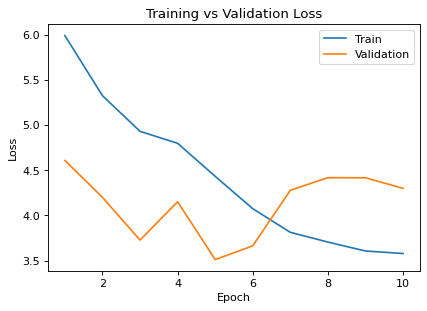

In [48]:
# Manually enter your epoch results
train_loss = [5.9917, 5.3263, 4.9313, 4.7988, 4.4331, 4.0749, 3.8130, 3.7052, 3.6064, 3.5785]
val_loss   = [4.6094, 4.2001, 3.7275, 4.1520, 3.5114, 3.6634,  4.2789, 4.4184, 4.4168, 4.3003]

#Training & Validation Loss Curves
epochs = range(1, len(train_loss) + 1)
plt.figure(figsize=(6, 4), dpi=80)
plt.plot(epochs, train_loss)
plt.plot(epochs, val_loss)
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Training vs Validation Loss")
plt.legend(["Train", "Validation"])
plt.show()

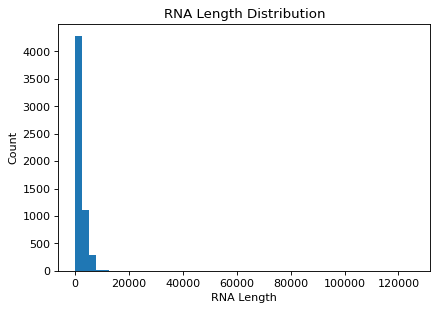

In [49]:
#RNA Length Distribution
import matplotlib.pyplot as plt
lengths = train_seq_df["sequence"].apply(len)
plt.figure(figsize=(6, 4), dpi=80)
plt.hist(lengths, bins=50)
plt.xlabel("RNA Length")
plt.ylabel("Count")
plt.title("RNA Length Distribution")
plt.show()

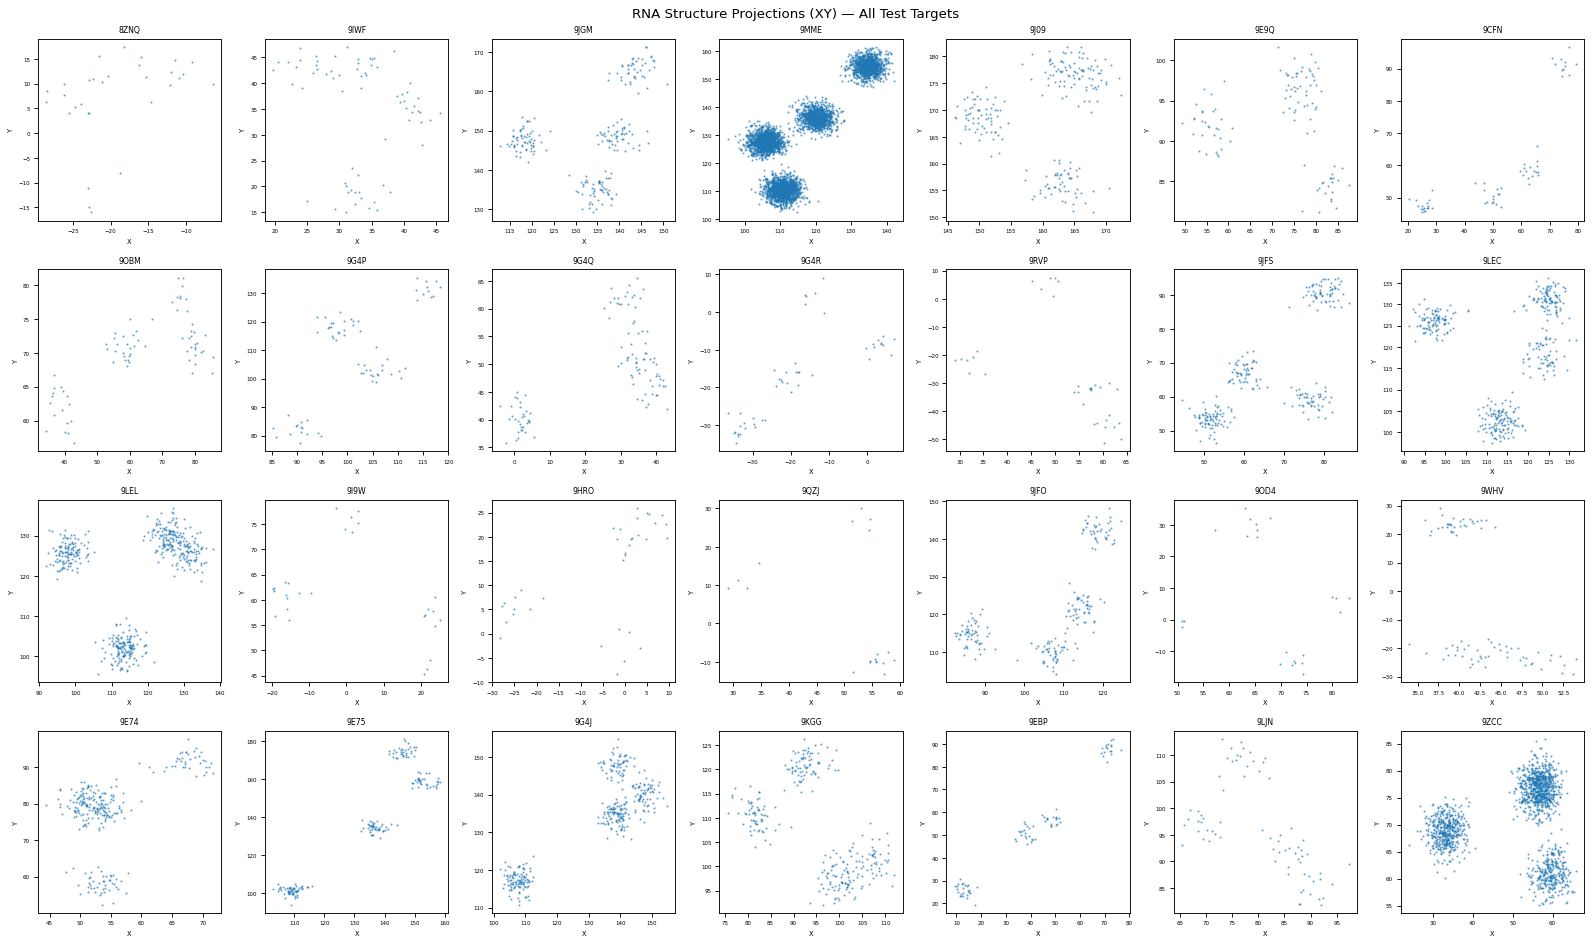

In [50]:
# Visualize all 28 test RNA structure projections
fig, axes = plt.subplots(4, 7, figsize=(20, 12), dpi=80)
axes = axes.flatten()
for idx, row in test_seq_df.iterrows():
    target_id = row["target_id"]
    seq_len   = min(len(row["sequence"]), CFG.MAX_SEQ_LEN)

    # Get prediction
    sample = build_sample(target_id, test_seq_df, structure_dict={})
    preds  = predict_5_structures(sample)

    # First conformation, denormalize, crop padding
    coords = preds[0].cpu().numpy() * 50.0
    coords = coords[:seq_len]
    ax = axes[idx]
    ax.scatter(coords[:, 0], coords[:, 1], s=1, alpha=0.5)
    ax.set_title(target_id, fontsize=7)
    ax.set_xlabel("X", fontsize=6)
    ax.set_ylabel("Y", fontsize=6)
    ax.tick_params(labelsize=5)
plt.suptitle("RNA Structure Projections (XY) — All Test Targets", fontsize=12)
plt.tight_layout()
plt.show()

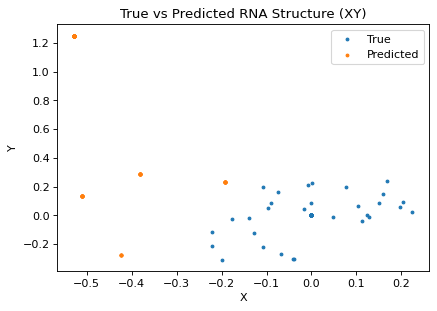

In [51]:
#Compare True vs Predicted Structure
sample = next(iter(val_loader))
seq_tokens = sample["seq_tokens"].to(CFG.DEVICE)
seq_mask   = sample["seq_mask"].to(CFG.DEVICE)
with torch.no_grad():
    preds = model(seq_tokens, seq_mask).cpu()
true = sample["coords"]
plt.figure(figsize=(6, 4), dpi=80)
plt.scatter(true[0,:,0], true[0,:,1], s=6)
plt.scatter(preds[0,:,0], preds[0,:,1], s=6)
plt.legend(["True", "Predicted"])
plt.title("True vs Predicted RNA Structure (XY)")
plt.xlabel("X")
plt.ylabel("Y")
plt.show()

In [52]:
# Build Kaggle submission
sample_sub = pd.read_csv(CFG.COMPETITION_DIR / "sample_submission.csv")
print("Sample sub shape:", sample_sub.shape)
print("Sample sub columns:", sample_sub.columns.tolist())

# Build lookup from test sequences for resname
test_resname_lookup = {}
for _, row in test_seq_df.iterrows():
    tid = row["target_id"]
    seq = row["sequence"]
    for i, nt in enumerate(seq):
        test_resname_lookup[f"{tid}_{i+1}"] = nt

# Build submission matching sample format exactly
submission_rows = []
for target_id, preds in test_predictions.items():
    seq = test_seq_df[test_seq_df["target_id"] == target_id].iloc[0]["sequence"]
    seq_len = len(seq)
    effective_len = min(seq_len, CFG.MAX_SEQ_LEN)
    for resid in range(1, effective_len + 1):
        row_id  = f"{target_id}_{resid}"
        resname = seq[resid - 1]
        row_dict = { "ID":      row_id, "resname": resname, "resid":   resid, }
        for i, coords_tensor in enumerate(preds):
            xyz = coords_tensor[resid - 1].cpu().numpy() * 50.0
            row_dict[f"x_{i+1}"] = float(xyz[0])
            row_dict[f"y_{i+1}"] = float(xyz[1])
            row_dict[f"z_{i+1}"] = float(xyz[2])
        submission_rows.append(row_dict)
submission_df = pd.DataFrame(submission_rows)
col_order = ["ID", "resname", "resid",
             "x_1","y_1","z_1",
             "x_2","y_2","z_2",
             "x_3","y_3","z_3",
             "x_4","y_4","z_4",
             "x_5","y_5","z_5"]
submission_df = submission_df[col_order]
print("Your submission shape:", submission_df.shape)
print("Expected shape:       ", sample_sub.shape)
print("Nulls:", submission_df.isnull().sum().sum())
#print(submission_df.head())

Sample sub shape: (9762, 18)
Sample sub columns: ['ID', 'resname', 'resid', 'x_1', 'y_1', 'z_1', 'x_2', 'y_2', 'z_2', 'x_3', 'y_3', 'z_3', 'x_4', 'y_4', 'z_4', 'x_5', 'y_5', 'z_5']
Your submission shape: (9762, 18)
Expected shape:        (9762, 18)
Nulls: 0


In [53]:
# Fill missing IDs with zeros and finalize submission
missing_ids = set(sample_sub["ID"]) - set(submission_df["ID"])
#print("Missing IDs:", len(missing_ids))

# Get missing rows from sample submission
missing_rows = sample_sub[sample_sub["ID"].isin(missing_ids)].copy()

# Zero out all coordinate columns
coord_cols_sub = ["x_1","y_1","z_1","x_2","y_2","z_2",
                  "x_3","y_3","z_3","x_4","y_4","z_4",
                  "x_5","y_5","z_5"]
missing_rows[coord_cols_sub] = 0.0
submission_final = pd.concat([submission_df, missing_rows], ignore_index=True)

# Sort to match sample submission order exactly
submission_final = submission_final.merge(
    sample_sub[["ID"]].reset_index().rename(columns={"index": "sort_order"}),
    on="ID"
).sort_values("sort_order").drop("sort_order", axis=1).reset_index(drop=True)

# Verify
print("Final shape:   ", submission_final.shape)
print("Expected shape:", sample_sub.shape)
print("Nulls:", submission_final.isnull().sum().sum())
#print(submission_final.head())

# Save final
submission_final.to_csv("submission.csv", index=False)
print("\nsubmission.csv saved")

Final shape:    (9762, 18)
Expected shape: (9762, 18)
Nulls: 0

submission.csv saved


In [54]:
print(submission_final.shape)
#print(submission_final.head())
#print(submission_final.isnull().sum())

#Download
from IPython.display import FileLink
FileLink("submission.csv")

(9762, 18)


/kaggle/working/submission.csv